In [1]:
import sys, importlib, os
sys.path.append(f'../../')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import itertools

from modules.loaders.visualize_training_data import animate_data
from modules.utils.numpy_torch_conversion import *
from modules.loaders.format_data import format_data_general
from modules.generate_data.simulate_system import *

In [2]:
def alex_reaction(species, params):
    rhoT, rhoD, pak, gef, pakc, gefc = species
    
    a, b, c, d, e, f, n = params
    
    F = np.zeros_like(species)

    F[0] = (a * gef**2 * rhoD) - b * rhoT
    F[1] = -((a * gef**2 * rhoD) - b * rhoT) * n
    F[2] = c * rhoT * pakc - d * pak
    F[3] = e * rhoT * gefc - f * pak * gef
    F[4] = n * (-c * rhoT * pakc + d * pak)
    F[5] = n * (-e * rhoT * gefc + f * pak * gef)
        
    return F

In [3]:
def laplace(M, dx, dim):
    if dim == 1:
        grid = (-2 * M + np.roll(M, 1) + np.roll(M, -1)) / dx**2
    
    elif dim == 2:
            grid = (-4 * M + np.roll(M, 1, axis=1) + np.roll(M, -1, axis=1) + 
                    np.roll(M, 1, axis=2) + np.roll(M, -1, axis=2)) / dx**2

    return grid

In [4]:
def update_laplace(u, reaction, params, diff_coeffs, dt, dx, points, dim, nn=None):
    if nn:
        F = to_numpy(reaction(to_torch(np.column_stack((u.ravel(), v.ravel())))))
        F = np.reshape(F, (points,)*dim)
        
    else:
        F = reaction(u, params)

    Lu = laplace(u, dx, dim)

    u = u + (diff_coeffs[:, None, None] * Lu + F) * dt
    
    return u


In [5]:
def simulate(ics, L, N, T, dim, species, reaction=wave_pinning, 
             params=[1, 1, 0.01], diff_coeffs=[0.01, 1], nn=None, save_name=None, 
             early_stop=True):
    
    if nn:
        reaction = nn.reaction
    
        if nn.diff:
            D = nn.diffusion_fitter()
            Du = D[0].detach().numpy()
            Dv = D[1].detach().numpy()

    # Define system parameters
    # dt = 0.0001
    dt = 0.0001
    # dx = L / N
    dx = ((L / 2) * np.sqrt(np.pi)) / N
    ss_tolerance = 0.005 if dim == 1 else 0.05
                
    nits = int(T / dt)
    half_sec_nits = 0.5 / dt

    x_array = np.linspace(0, L, N)
                   
    # Set up storage (only records at half second intervals)
    rows = int(nits / half_sec_nits) + 1

    u_array = np.zeros(((rows,) + (species,) + (N,)*dim))
    t_array = np.zeros(rows)
    
    # Set initial conditions
    u = ics
    
    # Solve
    for t in range(nits + 1):
        
        if t % (nits // 10) == 0:
            print(f"Progress: {(t / nits) * 100}%", flush=True)
            
        if t % half_sec_nits == 0:
            time_step = int(t / half_sec_nits)
            u_array[time_step, Ellipsis] = u
            t_array[time_step] = t * dt
            
            if early_stop == True:
                current_save = u_array[time_step]
                last_save = u_array[time_step-1]
                
                # Early stop if change over last 0.5 seconds below ss_tolerance
                if t > 0 and np.max(np.abs(current_save - last_save)) < ss_tolerance:
                    print(f'Steady state at t = {t * dt}', flush=True)
                    break
        
        u = update_laplace(u, reaction, params, diff_coeffs, dt, dx, N, dim, nn)

    # Remove zeros from arrays due to reaching steady state
    u_array_pre_ss = np.any(np.any(np.any(u_array != 0, axis=1), axis=1), axis=1)
    timestep_pre_ss = np.where(u_array_pre_ss)[0][-1]
    u_array = u_array[:timestep_pre_ss + 1]

    t_array = np.trim_zeros(t_array, 'b')    
    
    if save_name:
        np.savez(save_name, x_array, u_array, t_array)
                
    else:
        return x_array, u_array, t_array

In [6]:
# Define hyperparamters
L = 10
N = 100
T = 1000
dim = 2
species = 6

# Define simulation parameters
a = 0.8
b = 0.07 * 1.25
c = 0.03 
d = 0.04 
e = 0.05 
f = 0.025 * 1.25

# Calculate SA/V
r = L / 2
SA = 4 * np.pi * r**2
V = (4 / 3) * np.pi * r**3
mem_thickness = 0.01
n = (mem_thickness * SA) / V

params = np.array([a, b, c, d, e, f, n])

# Define diffusion coefficients
Dm = 0.01
Dc = 10
Dm2 = 0.1
diff_coeffs = np.array([Dm, Dc, Dm2, Dm, Dc, Dc])

# Define initial conditions
ics = np.zeros((species, N, N))
ics[0] = 5 * np.random.rand(N, N)   # Cdc42-GTPm
ics[1] = 0.5 - np.mean(ics[0]) * n   # Cdc42-GDPm should be 0.5
ics[2] = 1
ics[3] = 10 * np.random.rand(N, N)
ics[4] = 1
ics[5] = 0.5

In [ ]:
x_array, u_array, t_array = simulate(ics, L, N, T, dim, species, alex_reaction, params, diff_coeffs, save_name=None)

Progress: 0.0%


In [ ]:
def format_data_general(dimensions, species, file=None, x_array=None, 
                        t_array=None, u_array=None):
    if file is not None:
        # load data from npz file
        npz = np.load(file)
        
        x_array = npz[npz.files[0]]
        t_array = npz[npz.files[-1]]
        outputs = [npz[npz.files[i]] for i in range(1, len(npz.files)-1)]
    else:
        outputs = [u_array[:, 0], u_array[:, 1]]
        
    # create array of all points in n-dimensional space
    points = np.array(list(itertools.product(x_array, repeat=dimensions)))
    
    # create array to store formatted training data
    rows = len(t_array) * len(points)
    columns = dimensions + species + 1

    training_data = np.zeros((rows, columns))
    
    # load spatiotemporal coords into training data array
    i = 0

    for t in t_array:
        for point in points:
            inputs = np.hstack((point, t))
            training_data[i, : dimensions + 1] = inputs
            i += 1

    # load species concentrations into training data array
    i = dimensions + 1

    for array in outputs:
        training_data[:, i] = array.flatten()
        i += 1

    return training_data

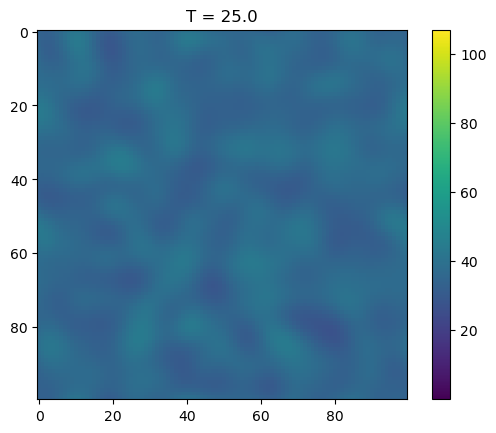

In [ ]:
format_data_general(2, 2, x_array=x_array, t_array=t_array, u_array=u_array)

sim_formatted = format_data_general(2, 2, x_array=x_array, t_array=t_array, u_array=u_array)

animate_data(sim_formatted, dim, 2, name='ayo!')